# [LAB-06] 15-2. 이중 축 그래프

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('traffic_acc')
origin.head()

📚 2005년 1월 부터 2018년 12월 까지 월별 교통사고의 발생건수,부상자수,사망자수 데이터(인덱스/메타데이터 없음, 출처: 공공데이터포털)


,년도,월,발생건수,사망자수,부상자수
0,2005,1,15494,504,25413
1,2005,2,13244,431,21635
2,2005,3,16580,477,25550
3,2005,4,17817,507,28131
4,2005,5,19085,571,29808


### 3. 데이터 전처리

각 변수를 년도별 평균값으로 전처리 한다.

In [3]:
df = origin.drop('월', axis=1).groupby('년도').mean()
df.head()

,발생건수,사망자수,부상자수
년도,,,
2005,17847.583,531.333,28519.417
2006,17812.083,527.250,28352.417
2007,17638.500,513.833,27992.167
2008,17985.167,489.167,28246.833
2009,19332.500,486.500,30156.250


## #02. 서브플롯의 초기화

### 1. 멀티 축을 갖는 캔버스 생성

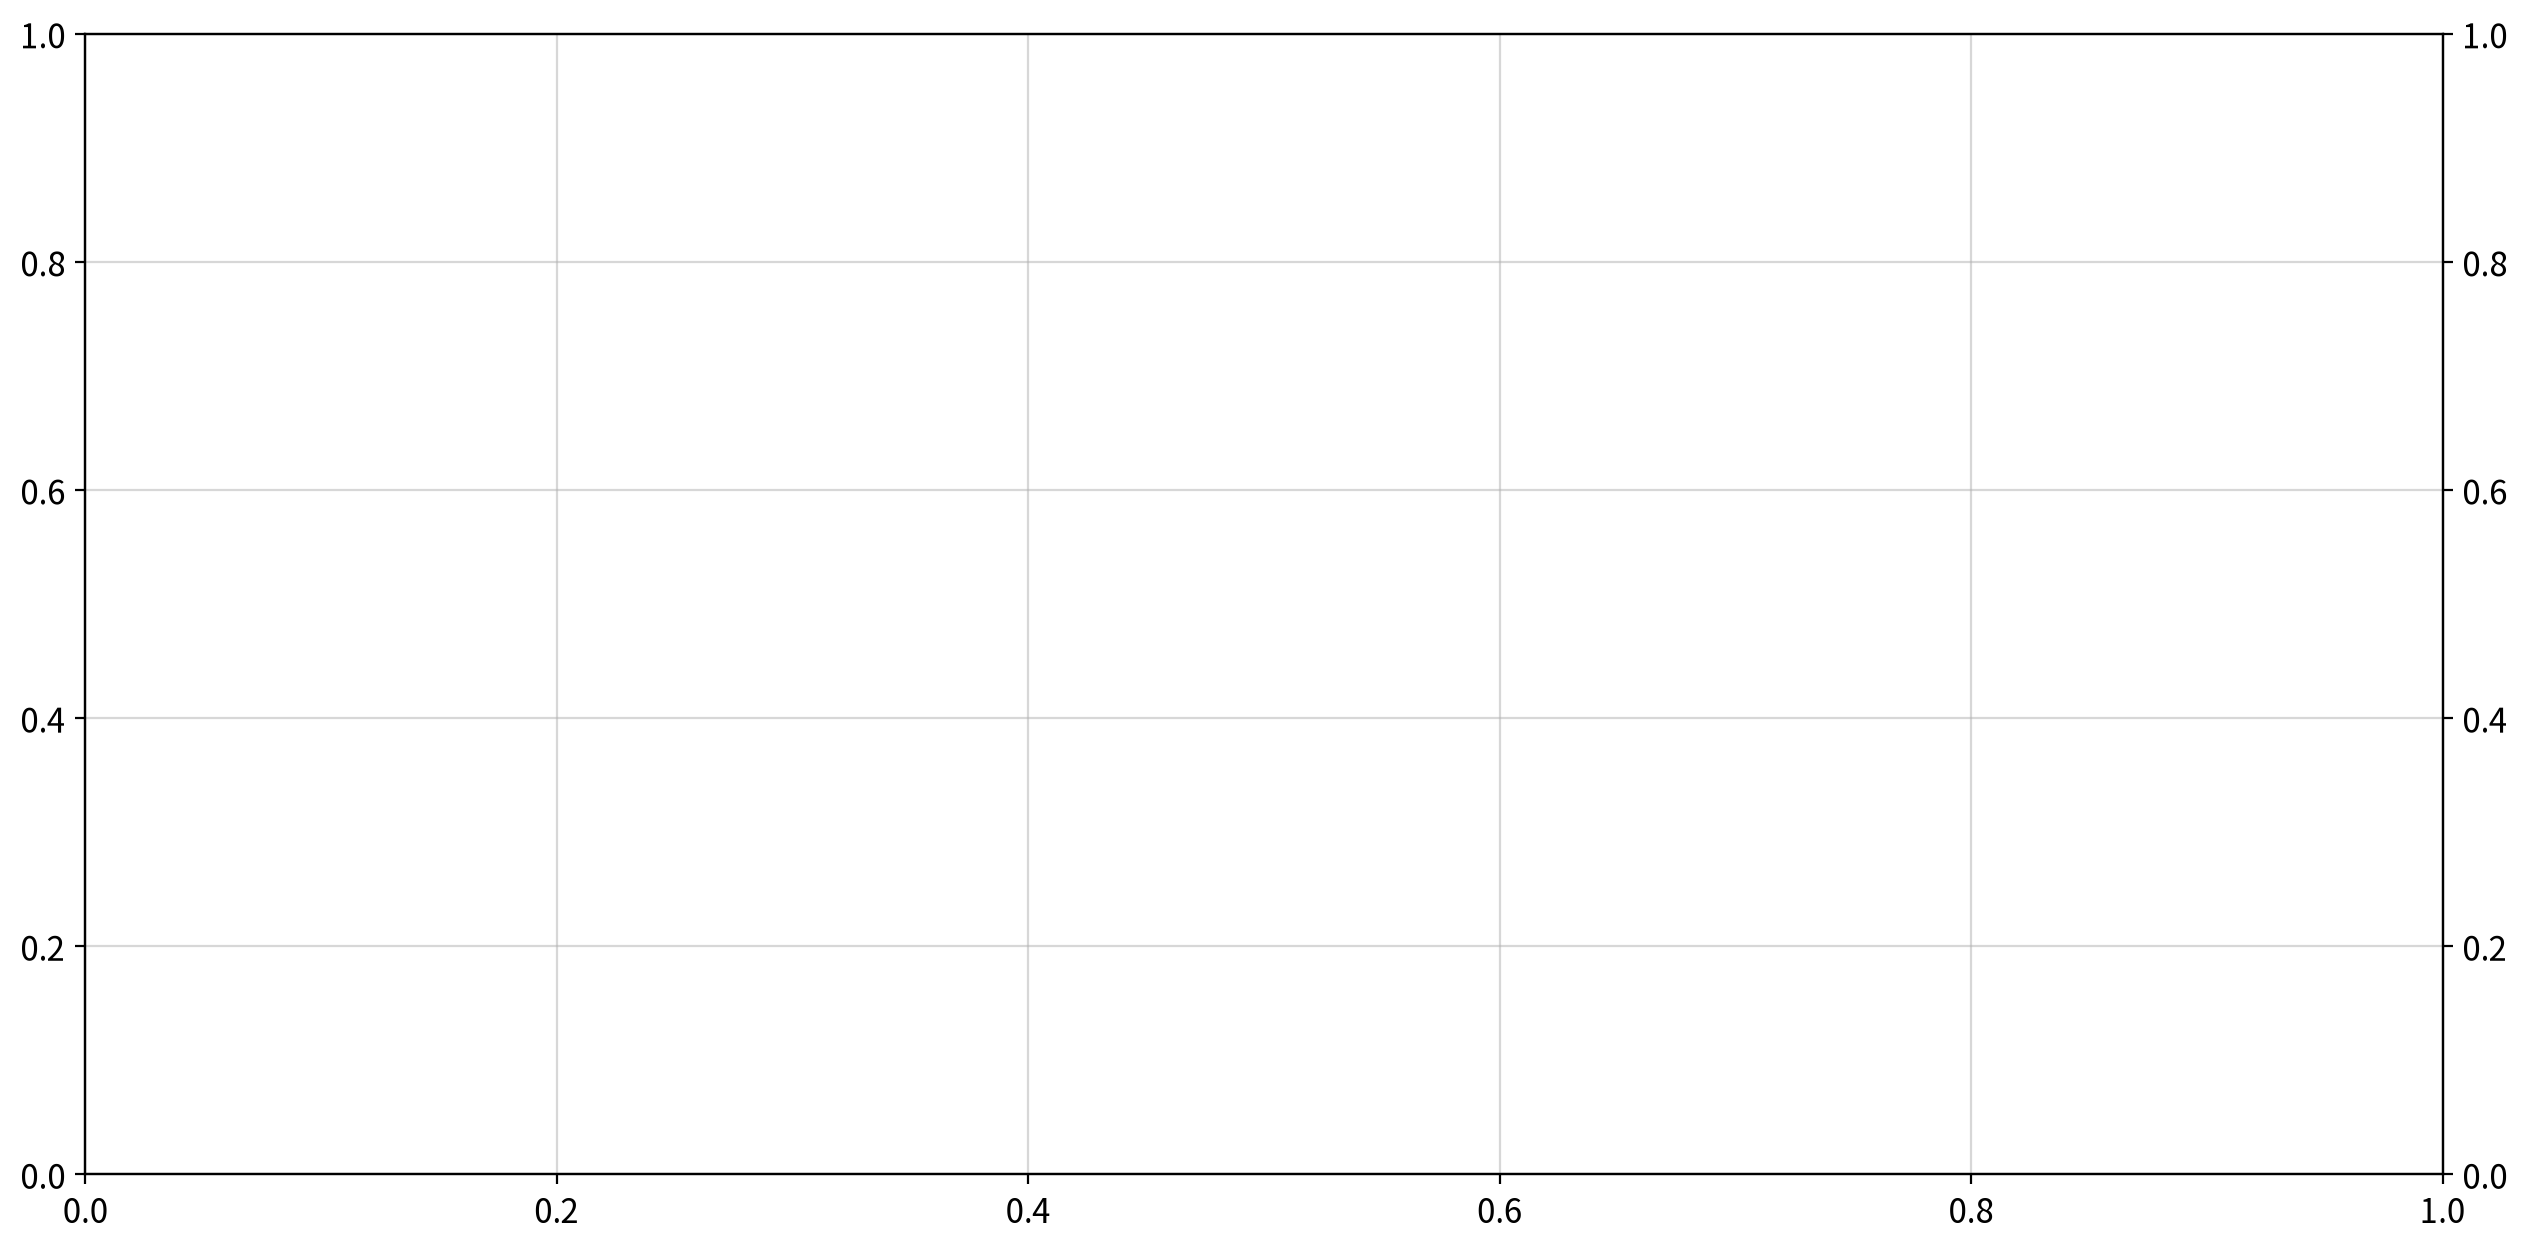

In [ ]:
fig, ax = my_plot.init()

# 쌍둥이 축을 만들어서 오른쪽에 추가
# -> ax가 왼쪽 축, ax_twinx가 오른쪽 축을 갖는 겹쳐진 그래프가 만들어짐
ax_twinx = ax.twinx()

# 관리에 용이하도록 ax와 ax_twinx를 튜플로 묶음 (리스트로도 가능)
ax = (ax, ax_twinx)

my_plot.show()

### 2. 멀티 축 그래프 모듈 기능 확인

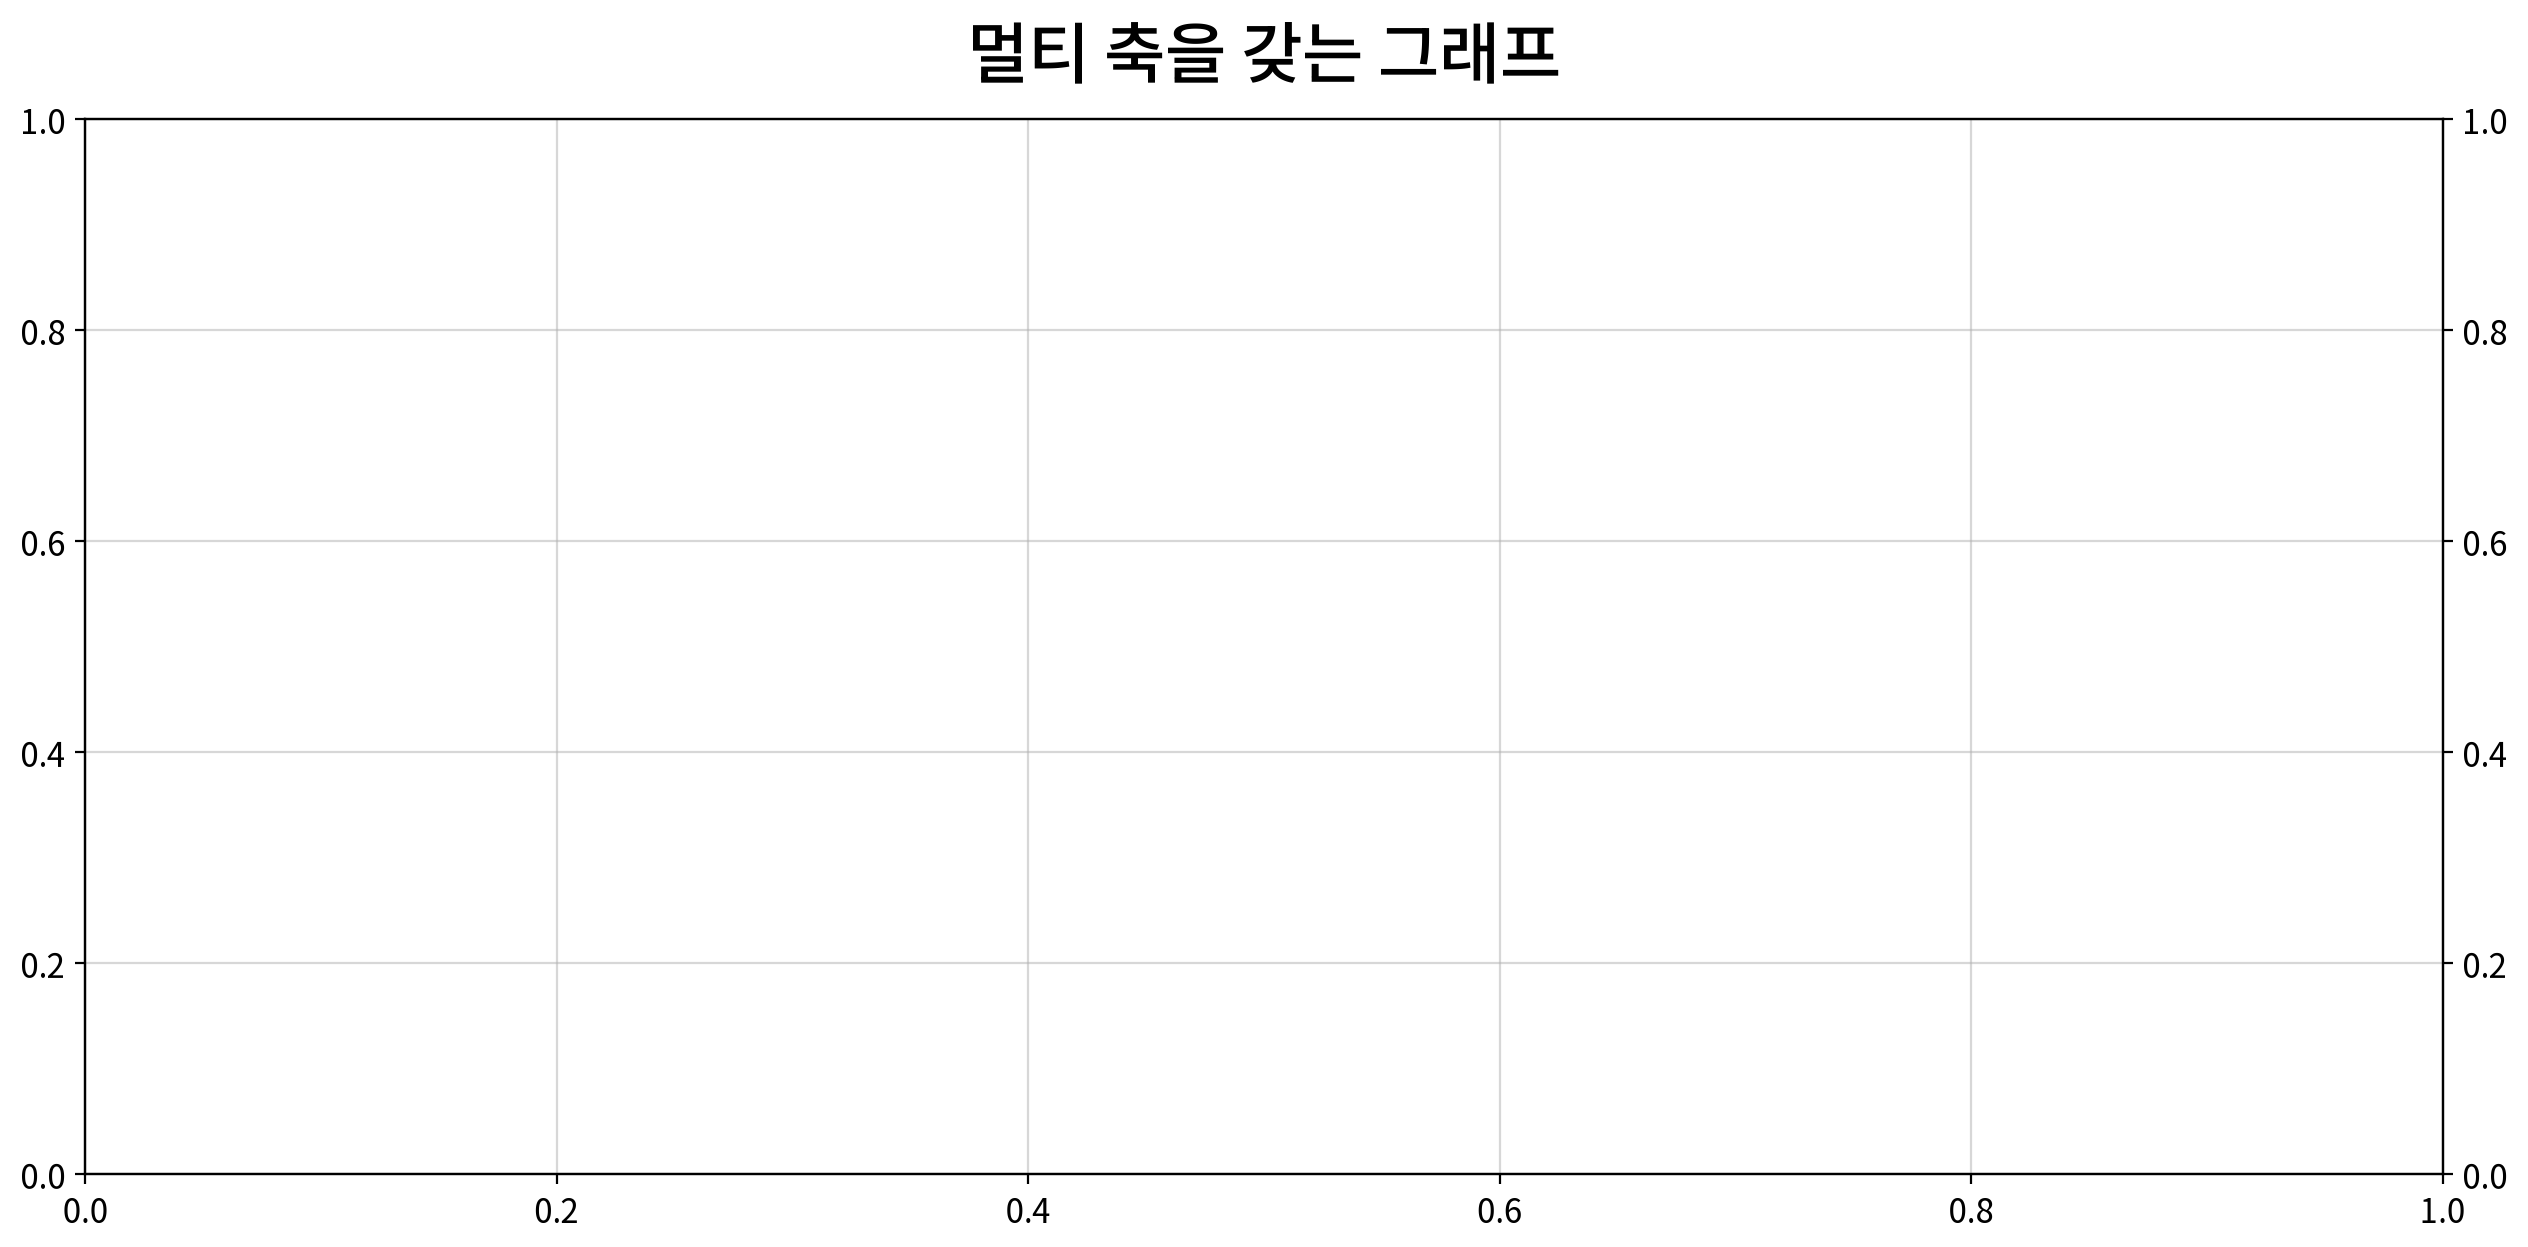

In [5]:
fig, ax = my_plot.init(title='멀티 축을 갖는 그래프', twinx=True)

my_plot.show()

## #03. 멀티 축에 그래프 표시하기

### 1. 교통사고 발생건수와 부상자수 추이 비교

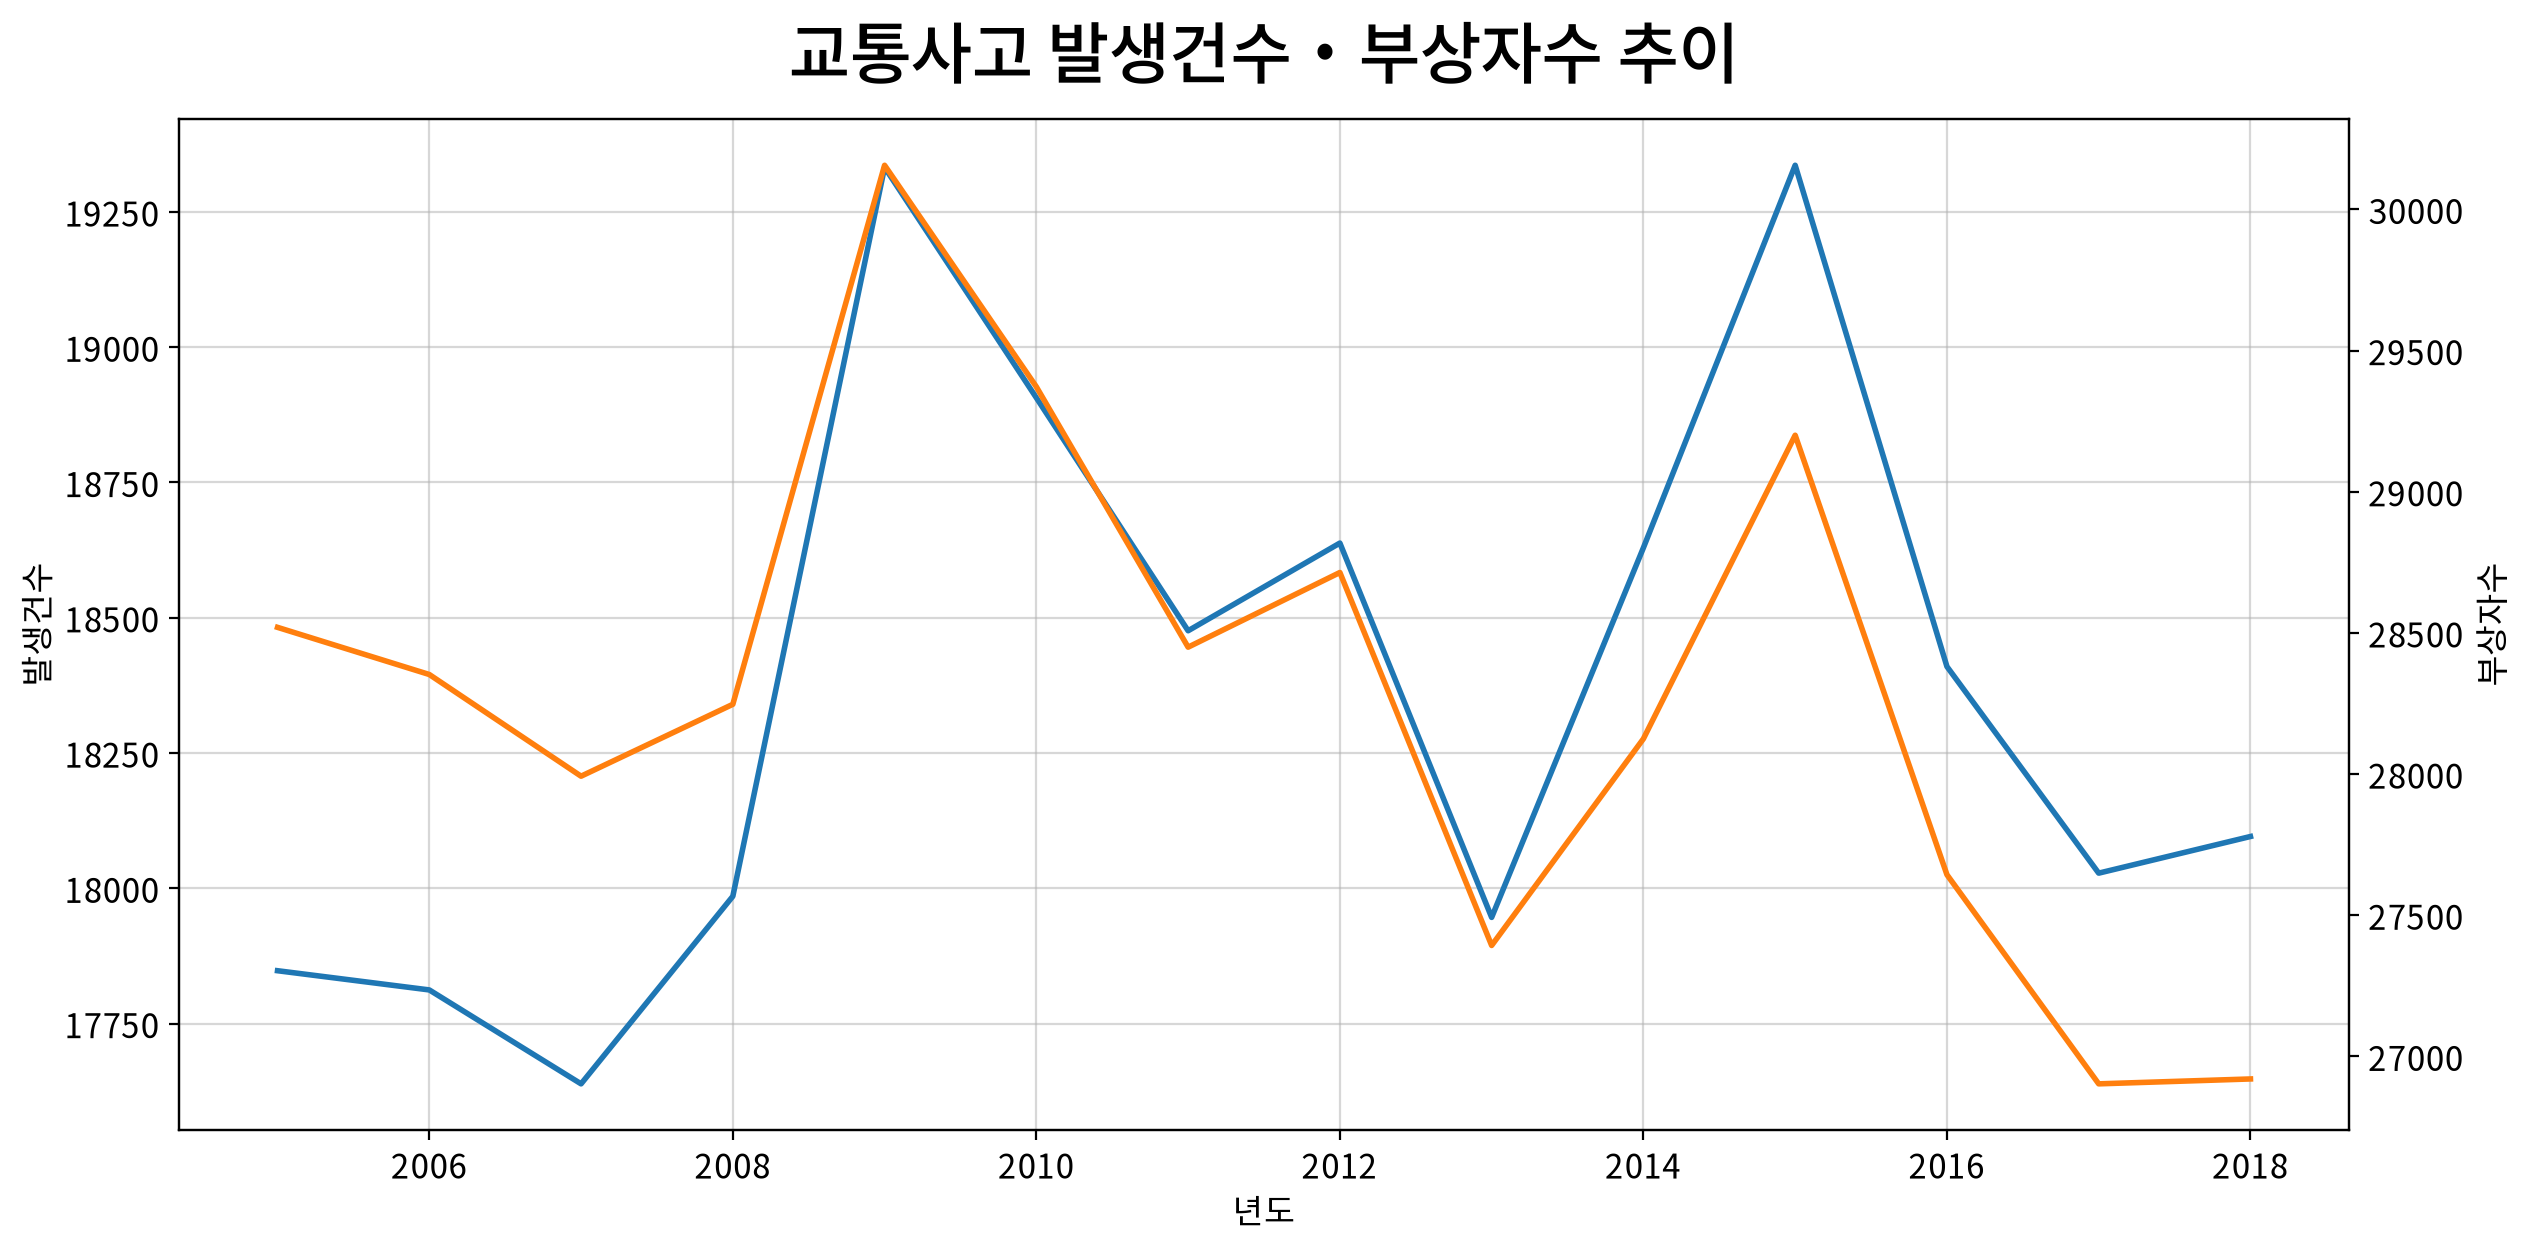

In [6]:
fig, ax = my_plot.init(title='교통사고 발생건수・부상자수 추이', twinx=True)

my_plot.lineplot(data=df, x=df.index, y='발생건수', ylabel='발생건수', 
                 color='tab:blue', ax=ax[0])
my_plot.lineplot(data=df, x=df.index, y='부상자수', ylabel='부상자수', 
                 color='tab:orange', ax=ax[1])

my_plot.show()

#### 💡 인사이트

- **2008년 고속도로 안전벨트 의무화 이후 초기 변화**: 2008~2009년에 발생건수와 부상자수가 증가세를 보임. 이는 의무화 초반 시행 과정에서의 통계적 변동으로 해석 가능

- **2010년 이후 지속적 감소 추세**: 2009년 최고점(발생건수 약 19,250건, 부상자수 약 30,500명)을 기준으로 2018년까지 전반적 감소 추세. 의무화가 안착되면서 안전 인식이 개선된 것으로 보임